# Imports

In [1]:
import torch
from torch import nn
from torch.nn import CrossEntropyLoss
from torch.utils.data import DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
from LabelMapper import LabelMapper
from RuralDataset import RuralDataset
from SegmentationModel import SegmentationModel
from Trainer import Trainer
from Evaluator import Evaluator
from ImageProcessor import ImageProcessor
from DiceLoss import DiceLoss

torch.cuda.empty_cache()

# Configuration parameters

In [2]:
DATA_ROOT = 'train'
BATCH_SIZE = 4
LEARNING_RATE = 0.001
NUM_EPOCHS = 10
NUM_CLASSES = 9
MODEL_SAVE_PATH = 'saved_model.pth'

# Device configuration

In [3]:
if torch.cuda.is_available():
    device = torch.device('cuda')  # Configura per utilizzare la GPU
    print(f"Utilizzo GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device('cpu')  # Fallback alla CPU
    print("CUDA non disponibile, utilizzo CPU")

Utilizzo GPU: NVIDIA GeForce RTX 5070 Ti


# Transforms initialization

In [4]:
train_transform = transforms.Compose([
    #transforms.Resize((272,512)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
val_transform = transforms.Compose([
    #transforms.Resize((272,512)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Dataset loading and splitting into training and validation sets

In [ ]:
# Crea dataset separati con le rispettive trasformazioni
from torch.utils.data import random_split

# Applica la trasformazione di training e validazione ai rispettivi dataset
full_dataset = RuralDataset(root_dir=DATA_ROOT)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

# Suddividi il dataset in train e val
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Applica le trasformazioni ai sotto-dataset
# NOTA: random_split restituisce Subset, quindi bisogna settare la transform manualmente
train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = val_transform

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, num_workers=8, shuffle=True,
    pin_memory=True)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, num_workers=8, shuffle=False,
    pin_memory=True)

print(f"Training on {len(train_dataset)} samples, validating on {len(val_dataset)} samples.")

Loading data from train:   0%|          | 0/932 [00:00<?, ?it/s]

# Model initialization

In [6]:
model = SegmentationModel()
model.to(device)
print("Model architecture:")
print(model)

Model architecture:
SegmentationModel(
  (double_conv_downs): ModuleList(
    (0): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): ReLU(inplace=True)
    )
    (1): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): ReLU(inplace=True)
    )
    (2): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
 

# Loss Function and optimizer definition

In [7]:
# weights = Trainer.compute_class_weights(train_loader,NUM_CLASSES).to(device)
# print(weights)

# 0: 11609844, 1: 41857083, 2: 61816044, 3: 64655385, 4: 57234268, 5: 149050513, 6: 24045406, 7: 730491, 8: 3450630
weights =[ 3.8332,  1.0790,  0.7218,  0.7481,  0.8233,  0.3108,  1.7673, 70.4379, 12.8048]
# weight=torch.tensor(weights, dtype=torch.float32).to(device)
# criterion = CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float32).to(device))
criterion = DiceLoss()
#criterion = CrossEntropyLoss()

In [8]:
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Trainer initialization and training

In [9]:
trainer = Trainer(model, train_loader, val_loader, criterion, optimizer, device)
print("\nStarting training...")
trainer.run(num_epochs=NUM_EPOCHS, model_save_path=MODEL_SAVE_PATH)
print("Training finished.")


Starting training...

Epoch 1/10


AttributeError: Caught AttributeError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "C:\Users\thatsrux\Desktop\ML_Project\ml-gr31\.venv\Lib\site-packages\torch\utils\data\_utils\worker.py", line 349, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
  File "C:\Users\thatsrux\Desktop\ML_Project\ml-gr31\.venv\Lib\site-packages\torch\utils\data\_utils\fetch.py", line 50, in fetch
    data = self.dataset.__getitems__(possibly_batched_index)
  File "C:\Users\thatsrux\Desktop\ML_Project\ml-gr31\.venv\Lib\site-packages\torch\utils\data\dataset.py", line 416, in __getitems__
    return [self.dataset[self.indices[idx]] for idx in indices]
            ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^
  File "C:\Users\thatsrux\Desktop\ML_Project\ml-gr31\RuralDataset.py", line 37, in __getitem__
    if t.__class.name__ == 'Resize':
       ^^^^^^^^^
AttributeError: 'ToTensor' object has no attribute '_RuralDataset__class'


# Model evaluation

In [12]:
model.load_state_dict(torch.load(MODEL_SAVE_PATH))

evaluator = Evaluator(model, val_loader, device)
metrics = evaluator.evaluate_classification_metrics()

# Example Predict

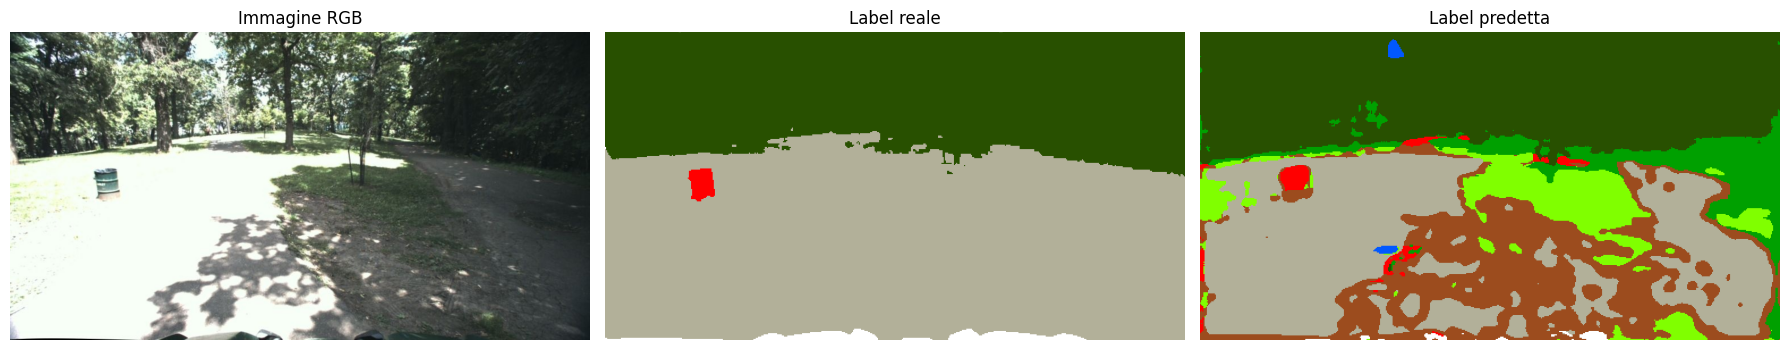

Pixel classificati correttamente: 90539 / 139264 (65.01%)
IoU medio sull'immagine: 0.2306
IoU per classe: [0.         0.         0.48210526 0.         0.90183124 0.
        nan 0.23021583]


In [17]:
evaluator.predict_from_folder(folder_number = 3)

In [14]:
print(metrics.get('accuracy', 'N/A'))
print(metrics.get('f1_score', 'N/A'))
print(metrics.get('precision', 'N/A'))
print(metrics.get('recall', 'N/A'))

0.6335870089180579
N/A
0.5332477544519518
0.4798870594048974
